
DATASET 1: LINEARLY SEPARABLE

DATASET 2: NON-LINEARLY SEPARABLE

Training Linearly Separable with logistic activation...


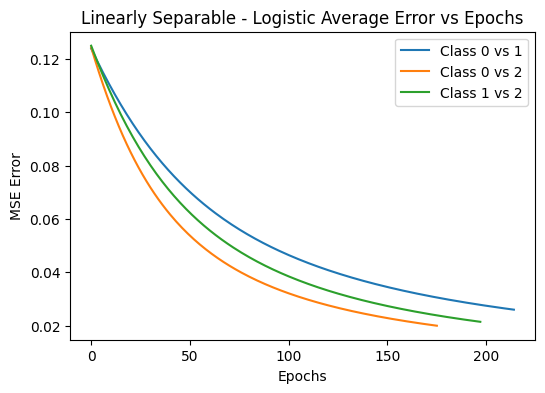

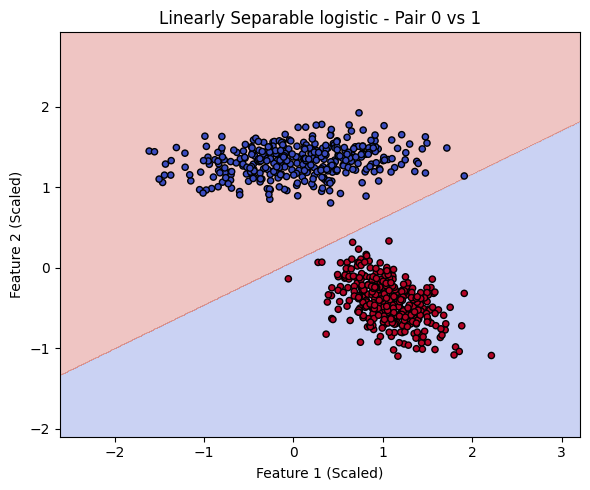

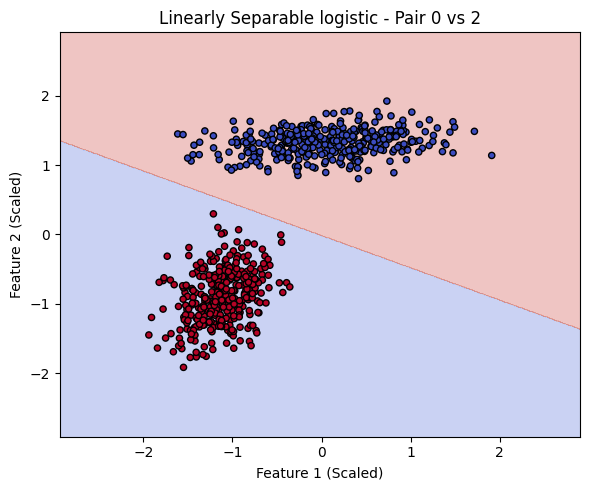

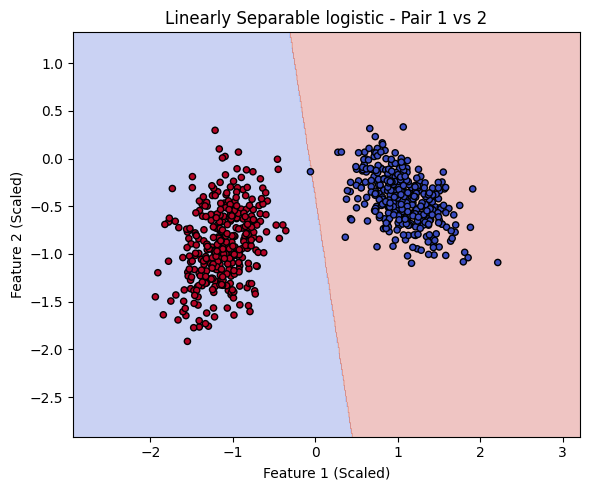

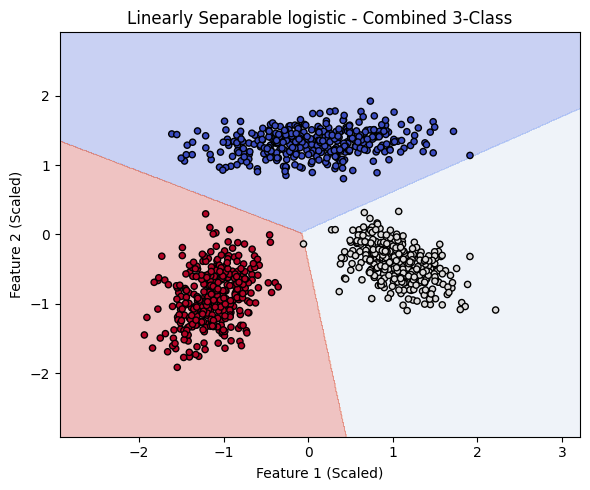

--- Test Results for Linearly Separable (logistic) ---
Confusion Matrix:
[[150   0   0]
 [  1 149   0]
 [  2   0 148]]
Accuracy: 99.33%
Class 0 -> Precision: 0.98, Recall: 1.00, F1: 0.99
Class 1 -> Precision: 1.00, Recall: 0.99, F1: 1.00
Class 2 -> Precision: 1.00, Recall: 0.99, F1: 0.99
Mean Precision: 0.99
Mean Recall: 0.99
Mean F1-Measure: 0.99


Training Linearly Separable with tanh activation...


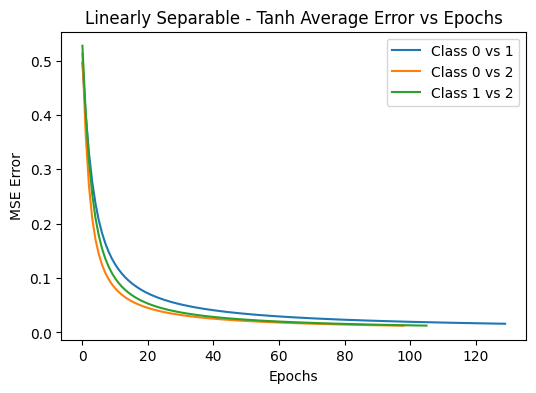

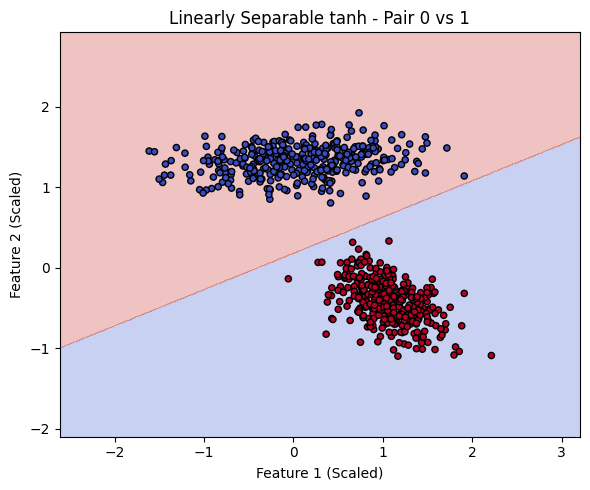

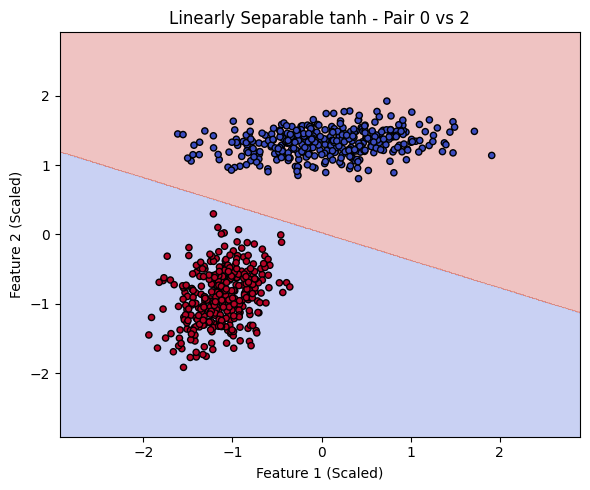

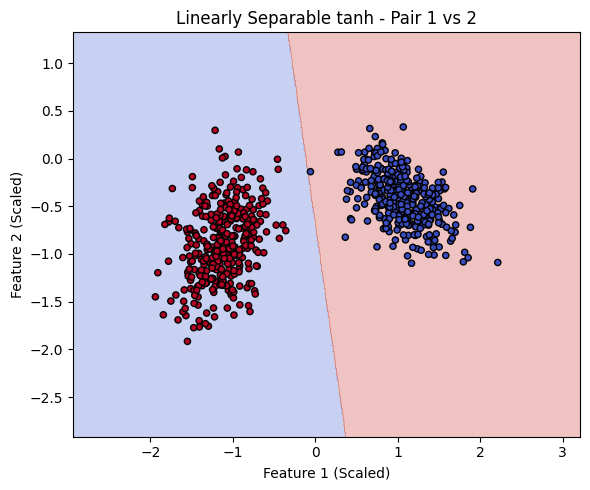

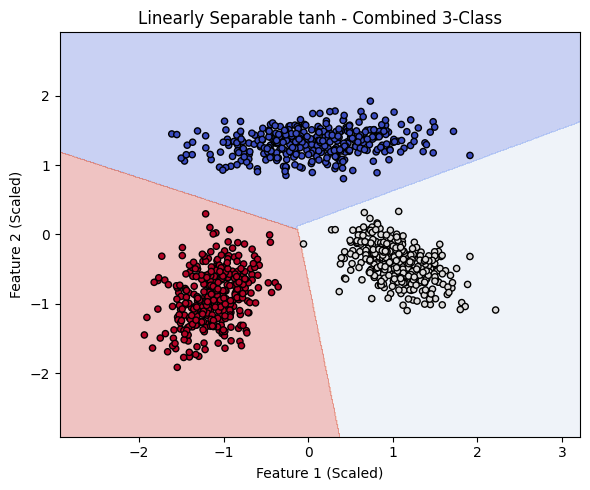

--- Test Results for Linearly Separable (tanh) ---
Confusion Matrix:
[[150   0   0]
 [  0 150   0]
 [  2   0 148]]
Accuracy: 99.56%
Class 0 -> Precision: 0.99, Recall: 1.00, F1: 0.99
Class 1 -> Precision: 1.00, Recall: 1.00, F1: 1.00
Class 2 -> Precision: 1.00, Recall: 0.99, F1: 0.99
Mean Precision: 1.00
Mean Recall: 1.00
Mean F1-Measure: 1.00


Training Non-Linearly Separable with logistic activation...


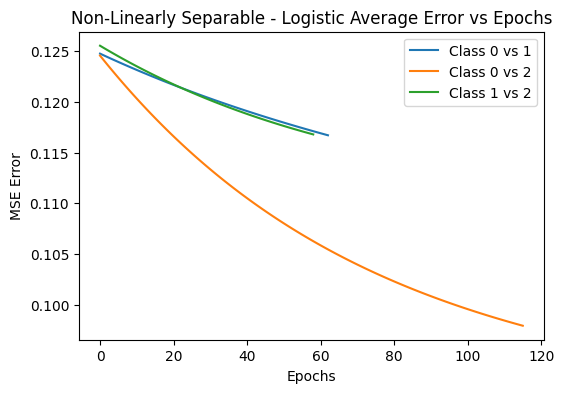

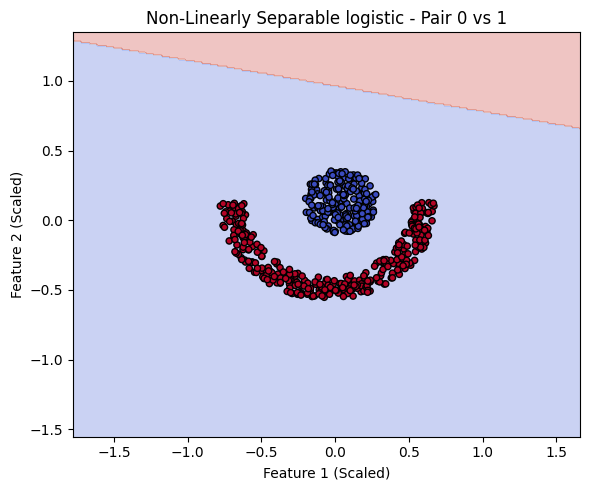

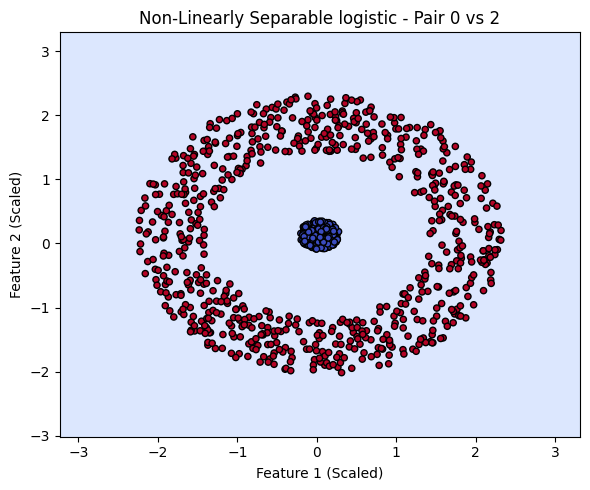

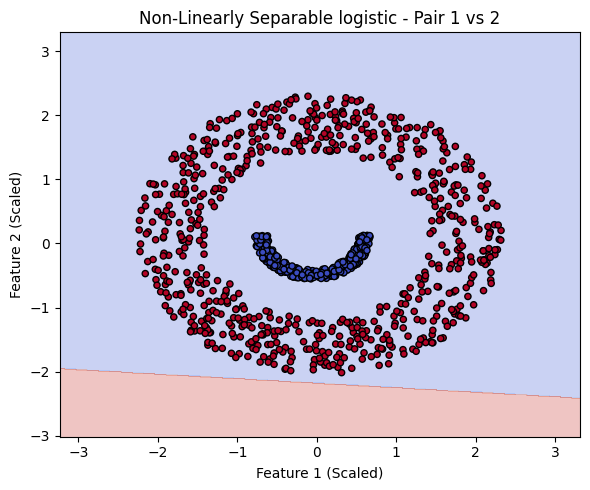

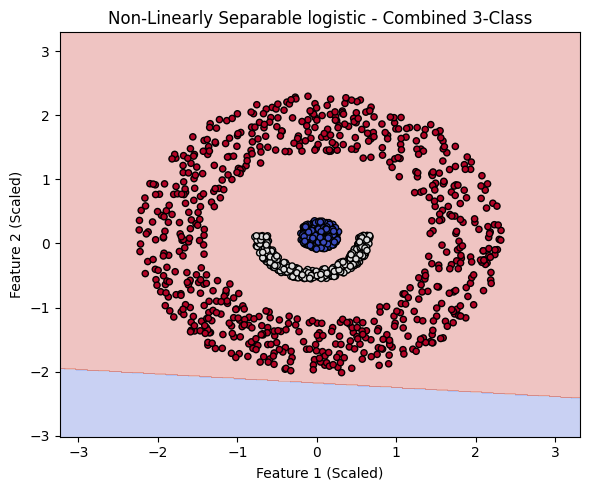

--- Test Results for Non-Linearly Separable (logistic) ---
Confusion Matrix:
[[  0   0  90]
 [  0   0 150]
 [  0   0 300]]
Accuracy: 55.56%
Class 0 -> Precision: 0.00, Recall: 0.00, F1: 0.00
Class 1 -> Precision: 0.00, Recall: 0.00, F1: 0.00
Class 2 -> Precision: 0.56, Recall: 1.00, F1: 0.71
Mean Precision: 0.19
Mean Recall: 0.33
Mean F1-Measure: 0.24


Training Non-Linearly Separable with tanh activation...


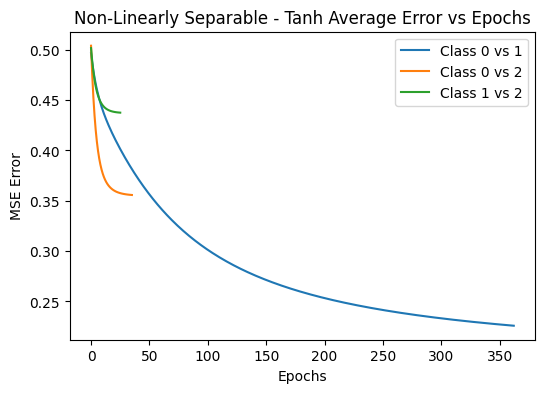

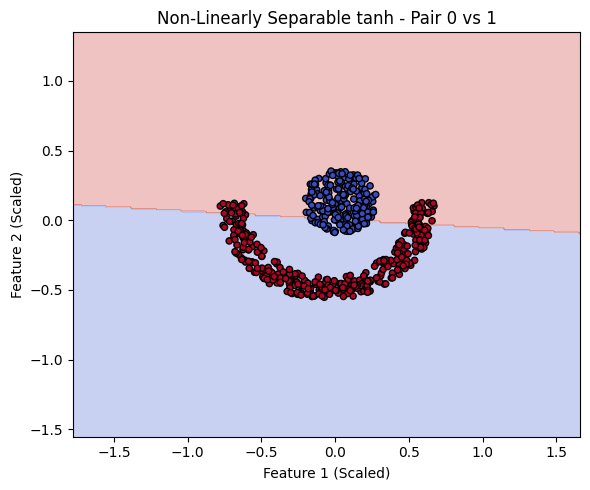

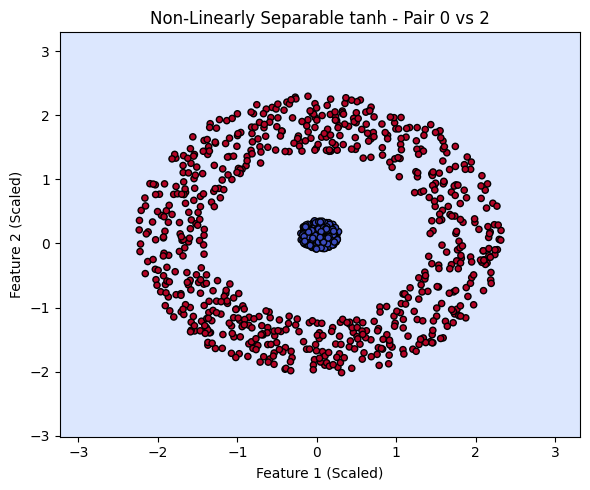

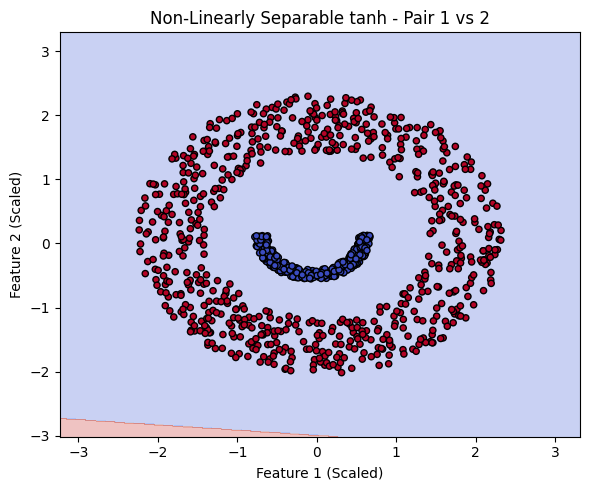

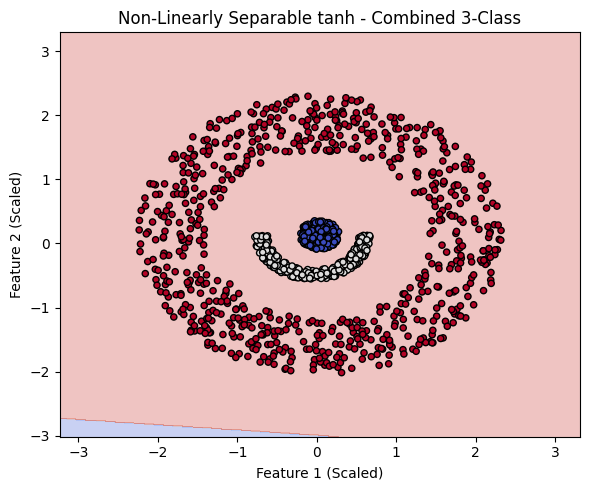

--- Test Results for Non-Linearly Separable (tanh) ---
Confusion Matrix:
[[  0   0  90]
 [  0   0 150]
 [  0   0 300]]
Accuracy: 55.56%
Class 0 -> Precision: 0.00, Recall: 0.00, F1: 0.00
Class 1 -> Precision: 0.00, Recall: 0.00, F1: 0.00
Class 2 -> Precision: 0.56, Recall: 1.00, F1: 0.71
Mean Precision: 0.19
Mean Recall: 0.33
Mean F1-Measure: 0.24



In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PERCEPTRON FROM SCRATCH 
# ==========================================
class Perceptron:
    # ADDED 'tol' for convergence criterion
    def __init__(self, input_dim, activation='logistic', lr=0.1, epochs=2000, tol=1e-4):
        self.weights = np.random.randn(input_dim + 1) * 0.01
        self.activation = activation
        self.lr = lr
        self.epochs = epochs
        self.tol = tol
        self.loss_history = []

    def _activate(self, z):
        if self.activation == 'logistic':
            # np.clip prevents overflow errors in exp
            z = np.clip(z, -250, 250)
            return 1 / (1 + np.exp(-z))
        elif self.activation == 'tanh':
            return np.tanh(z)

    def _activate_derivative(self, a):
        if self.activation == 'logistic':
            return a * (1 - a)
        elif self.activation == 'tanh':
            return 1 - a**2

    def train(self, X, y):
        n_samples = X.shape[0]
        X_aug = np.c_[np.ones(n_samples), X]
        
        prev_loss = float('inf')
        
        for epoch in range(self.epochs):
            z = np.dot(X_aug, self.weights)
            a = self._activate(z)
            
            error = y - a
            current_loss = np.mean(0.5 * error**2)
            self.loss_history.append(current_loss)
            
            # --- CONVERGENCE CRITERION ---
            if abs(prev_loss - current_loss) < self.tol:
                # Uncomment the print statement below if you want to see exactly when it stops
                # print(f"Converged at epoch {epoch}")
                break
            prev_loss = current_loss
            
            dz = -error * self._activate_derivative(a)
            dw = np.dot(X_aug.T, dz) / n_samples
            
            self.weights -= self.lr * dw

    def predict(self, X):
        X_aug = np.c_[np.ones(X.shape[0]), X]
        z = np.dot(X_aug, self.weights)
        a = self._activate(z)
        
        if self.activation == 'logistic':
            return np.where(a >= 0.5, 1, 0)
        elif self.activation == 'tanh':
            return np.where(a >= 0.0, 1, -1)

# ==========================================
# 2. ONE-VS-ONE MULTICLASS CLASSIFIER
# ==========================================
class OVOClassifier:
    def __init__(self, num_classes=3, activation='logistic', lr=0.1, epochs=2000, tol=1e-4):
        self.num_classes = num_classes
        self.activation = activation
        self.lr = lr
        self.epochs = epochs
        self.tol = tol
        self.models = {}

    def train(self, X, y):
        for i in range(self.num_classes):
            for j in range(i + 1, self.num_classes):
                idx = np.where((y == i) | (y == j))[0]
                X_pair, y_pair = X[idx], y[idx]
                
                if self.activation == 'logistic':
                    y_target = np.where(y_pair == i, 1, 0)
                else:
                    y_target = np.where(y_pair == i, 1, -1)
                
                model = Perceptron(input_dim=X.shape[1], activation=self.activation, 
                                   lr=self.lr, epochs=self.epochs, tol=self.tol)
                model.train(X_pair, y_target)
                self.models[(i, j)] = model

    def predict(self, X):
        votes = np.zeros((X.shape[0], self.num_classes))
        for (i, j), model in self.models.items():
            preds = model.predict(X)
            for k in range(X.shape[0]):
                if preds[k] == 1:
                    votes[k, i] += 1
                else:
                    votes[k, j] += 1
        return np.argmax(votes, axis=1)

# ==========================================
# 3. HELPER FUNCTIONS
# ==========================================
def prepare_data(class_data_list):
    X_train, y_train, X_test, y_test = [], [], [], []
    
    for label, data in enumerate(class_data_list):
        n_samples = data.shape[0]
        split_idx = int(n_samples * 0.7)
        
        X_train.append(data[:split_idx])
        y_train.append(np.full(split_idx, label))
        
        X_test.append(data[split_idx:])
        y_test.append(np.full(n_samples - split_idx, label))
        
    X_train = np.vstack(X_train)
    y_train = np.concatenate(y_train)
    X_test = np.vstack(X_test)
    y_test = np.concatenate(y_test)
    
    # --- ADDED: FEATURE SCALING (Solves the LS Data issue) ---
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)
    
    X_train_scaled = (X_train - mean) / (std + 1e-8)
    X_test_scaled = (X_test - mean) / (std + 1e-8)
    
    return X_train_scaled, y_train, X_test_scaled, y_test

def plot_decision_regions(X, y, classifier, title, pair=None):
    plt.figure(figsize=(6, 5))
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    if pair is not None:
        Z = classifier.models[pair].predict(grid)
    else:
        Z = classifier.predict(grid)
        
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap='coolwarm', s=20)
    plt.title(title)
    plt.xlabel('Feature 1 (Scaled)')
    plt.ylabel('Feature 2 (Scaled)')
    plt.tight_layout()
    plt.show()

def evaluate_metrics(y_true, y_pred, num_classes=3):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
        
    accuracy = np.sum(np.diag(cm)) / np.sum(cm)
    precisions, recalls, f1s = [], [], []
    
    for i in range(num_classes):
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        fn = np.sum(cm[i, :]) - tp
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        
    print(f"Confusion Matrix:\n{cm}")
    print(f"Accuracy: {accuracy*100:.2f}%")
    for i in range(num_classes):
        print(f"Class {i} -> Precision: {precisions[i]:.2f}, Recall: {recalls[i]:.2f}, F1: {f1s[i]:.2f}")
    print(f"Mean Precision: {np.mean(precisions):.2f}")
    print(f"Mean Recall: {np.mean(recalls):.2f}")
    print(f"Mean F1-Measure: {np.mean(f1s):.2f}\n")

# ==========================================
# 4. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    print("\n" + "="*40 + "\nDATASET 1: LINEARLY SEPARABLE\n" + "="*40)
    ls_c1 = np.loadtxt('Classification/LS_Group24/Class1.txt')
    ls_c2 = np.loadtxt('Classification/LS_Group24/Class2.txt')
    ls_c3 = np.loadtxt('Classification/LS_Group24/Class3.txt')
    X_train_ls, y_train_ls, X_test_ls, y_test_ls = prepare_data([ls_c1, ls_c2, ls_c3])

    print("\n" + "="*40 + "\nDATASET 2: NON-LINEARLY SEPARABLE\n" + "="*40)
    nls_data = np.loadtxt('Classification/NLS_Group24.txt', skiprows=1)
    nls_c1 = nls_data[:300]
    nls_c2 = nls_data[300:800]
    nls_c3 = nls_data[800:1800]
    X_train_nls, y_train_nls, X_test_nls, y_test_nls = prepare_data([nls_c1, nls_c2, nls_c3])

    datasets = [
        ("Linearly Separable", X_train_ls, y_train_ls, X_test_ls, y_test_ls),
        ("Non-Linearly Separable", X_train_nls, y_train_nls, X_test_nls, y_test_nls)
    ]

    for name, X_tr, y_tr, X_te, y_te in datasets:
        for activation in ['logistic', 'tanh']:
            print(f"\nTraining {name} with {activation} activation...")
            # Note: Increased lr and epochs slightly, though convergence criterion will stop it early
            model = OVOClassifier(num_classes=3, activation=activation, lr=0.1, epochs=2000, tol=1e-4)
            model.train(X_tr, y_tr)
            
            plt.figure(figsize=(6,4))
            for pair, perceptron in model.models.items():
                plt.plot(perceptron.loss_history, label=f"Class {pair[0]} vs {pair[1]}")
            plt.title(f"{name} - {activation.capitalize()} Average Error vs Epochs")
            plt.xlabel("Epochs")
            plt.ylabel("MSE Error")
            plt.legend()
            plt.show()

            for pair in model.models.keys():
                pair_idx = np.where((y_tr == pair[0]) | (y_tr == pair[1]))[0]
                plot_decision_regions(X_tr[pair_idx], y_tr[pair_idx], model, 
                                      f"{name} {activation} - Pair {pair[0]} vs {pair[1]}", pair=pair)
            
            plot_decision_regions(X_tr, y_tr, model, f"{name} {activation} - Combined 3-Class")

            print(f"--- Test Results for {name} ({activation}) ---")
            y_pred = model.predict(X_te)
            evaluate_metrics(y_te, y_pred)